In [41]:
import os
import random
import pickle as pkl
from tqdm import tqdm
import math

from dataclasses import dataclass

from sklearn.linear_model import LogisticRegression

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

from scipy.special import softmax
import torch
import numpy as np
import re
from sklearn.model_selection import train_test_split
from transformers import pipeline
import pandas as pd

from personal_llm.utils import *
from scipy.stats import dirichlet

import matplotlib.pyplot as plt
plt.style.use('seaborn-v0_8')
import matplotlib.pylab as plt


In [4]:
import nltk
from nltk.tokenize import word_tokenize
from nltk import pos_tag
# from sklearn.feature_extraction.text import CountVectorizer
# from sklearn.model_selection import train_test_split
# from sklearn.ensemble import RandomForestClassifier
# from sklearn.metrics import accuracy_score, classification_report
import string
from nltk.corpus import stopwords

# Download NLTK resources
nltk.download('punkt')
nltk.download('averaged_perceptron_tagger')

# Download additional NLTK resources
nltk.download('stopwords')

[nltk_data] Downloading package punkt to /home/tpz2105/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /home/tpz2105/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package stopwords to
[nltk_data]     /home/tpz2105/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [76]:
# Feature extraction function with additional features
def extract_syntactic_features(text):
    tokens = word_tokenize(text)
    pos_tags = pos_tag(tokens)
    stop_words = set(stopwords.words('english'))
    punctuation_marks = set(string.punctuation)

    lines = text.splitlines()

    num_bullets = sum(1 for line in lines if re.match(r'^\s*[-*•]', line))
    num_numbered = sum(1 for line in lines if re.match(r'^\s*\d+\.', line))
    
    features = {
        'text_length': len(tokens),
        'num_unique_words': len(set(tokens)),
        'avg_word_length': sum(len(word) for word in tokens) / len(tokens) if tokens else 0,
        'num_stopwords': len([word for word in tokens if word.lower() in stop_words]),
        'num_punctuation': len([char for char in text if char in punctuation_marks]),
        # 'num_nouns': len([word for word, pos in pos_tags if pos.startswith('N')]),
        # 'num_verbs': len([word for word, pos in pos_tags if pos.startswith('V')]),
        # 'num_adjectives': len([word for word, pos in pos_tags if pos.startswith('J')]),
        # 'num_adverbs': len([word for word, pos in pos_tags if pos.startswith('R')]),
        'num_format': num_numbered+num_bullets,
        'num_adjectives_adverbs': len([word for word, pos in pos_tags if pos.startswith('J')]) + len([word for word, pos in pos_tags if pos.startswith('R')]),
        # 'num_pronouns': len([word for word, pos in pos_tags if pos.startswith('PRP') or pos == 'PRP$']),
        # 'num_determiners': len([word for word, pos in pos_tags if pos == 'DT']),
        # 'num_capitalized': len([word for word in tokens if word[0].isupper()]),
        # 'contains_format': int((num_bullets > 0) or (num_numbered > 0))
    }
    return features


def get_syntax_scores(args):

    syntax_path = "../data/all_syntax_scores.pkl"
    # if os.path.exists(syntax_path):
    if False:
        with open(syntax_path, "rb") as f:
            feature_list, syntax_scores = pkl.load(f)
    else:
        syntax_scores = []
        feature_list = None
        for i in tqdm(range(args.n_response)):
            responses = test_data["response_{}".format(i+1)].tolist()
            features = [extract_syntactic_features(text) for text in responses]
            feature_list = list(features[0].keys())
            syntax_scores.append(
                [
                    list(f.values()) for f in features
                ]
            )
        syntax_scores = np.array(syntax_scores)
        with open(syntax_path, "wb") as f:
            data = (feature_list, syntax_scores)
            pkl.dump(data, f)
    return feature_list, syntax_scores

In [6]:
def get_person_choices(w_person, data, reward_models, n_response, rank_ind=0):

    person_choices = []
    for i in range(len(data)):

        row = data.iloc[i]
        item_scores = []
        for rm_idx, rm in enumerate(reward_models):
            rm_scores = []
            for j in range(n_response):
                score = row["response_{}_{}".format(j+1, rm)]
                rm_scores.append(score)
            # if args.softmax:
            #     rm_scores = softmax(np.array(rm_scores)) * w_person[rm_idx]
            # else:
            #     rm_scores = np.array(rm_scores) * w_person[rm_idx]
            rm_scores = np.array(rm_scores) * w_person[rm_idx]
            item_scores.append(rm_scores)

        item_scores = np.array(item_scores)
        item_scores = np.sum(item_scores, 0)
        sorted_ind = np.argsort(-item_scores)
        # print("sorted ind", sorted_ind)
        # print("argmin", np.argmin(item_scores))
        # print("argmax", np.argmax(item_scores))
        # e += 7
        person_choices.append(sorted_ind[rank_ind])
        # if args.worst_response:
            # person_choices.append()
        # else:
            # person_choices.append(np.argmax(item_scores))

    return person_choices
 

In [8]:
@dataclass
class Args:
    seed: int=0
    alpha: float=0.05
    n_persons: int=1000
    quantity_on_hand: int = 0
    worst_response: bool=False
    softmax: bool=False
    n_response: int=8


args = Args()

In [9]:
np.random.seed(args.seed)
random.seed(args.seed)
torch.manual_seed(args.seed)

_, reward_models = get_persons_and_reward_models()
_, test_data = get_data()

n_rm = len(reward_models)
alphas = np.array([args.alpha]*n_rm)
print("alphas", alphas)
persons = dirichlet.rvs(alphas, size=args.n_persons, random_state=args.seed)
print("persons", persons.shape)

alphas [0.05 0.05 0.05 0.05 0.05 0.05 0.05 0.05 0.05 0.05]
persons (1000, 10)


In [10]:
args.worst_response = False
response_quality = "best"
if args.worst_response:
    response_quality = "worst"

all_choices = []
for i in range(persons.shape[0]):
    person = persons[i]
    choices = get_person_choices(person, test_data, reward_models, args.n_response, rank_ind=0)

    all_choices.append(choices)
best_choices = np.array(all_choices)
print("best choices", best_choices.shape)

best choices (1000, 1000)


In [11]:
args.worst_response = True
if args.worst_response:
    response_quality = "worst"

all_choices = []
for i in range(persons.shape[0]):
    person = persons[i]
    choices = get_person_choices(person, test_data, reward_models, args.n_response, rank_ind=3)

    all_choices.append(choices)
worst_choices = np.array(all_choices)
print("worst choices", worst_choices.shape)

worst choices (1000, 1000)


In [77]:
feature_list, syntax_scores = get_syntax_scores(args)

100%|██████████| 8/8 [01:53<00:00, 14.21s/it]


In [78]:
# syntax_scores = syntax_scores[:,:,2:]
# feature_list = feature_list[2:]


In [79]:
print(feature_list)
print(syntax_scores.shape)

['text_length', 'num_unique_words', 'avg_word_length', 'num_stopwords', 'num_punctuation', 'num_format', 'num_adjectives_adverbs']
(8, 1000, 7)


In [80]:
best_syntax_feat = []
for i in range(persons.shape[0]):
    p_choices = best_choices[i]
    p_choices = p_choices.tolist()
    p_f_scores = syntax_scores[p_choices, np.arange(len(p_choices)), :]
    best_syntax_feat.append(p_f_scores)
best_response_features = np.array(best_syntax_feat)
print(best_response_features.shape)

(1000, 1000, 7)


In [81]:
worst_syntax_feat = []
for i in range(persons.shape[0]):
    p_choices = worst_choices[i]
    p_choices = p_choices.tolist()
    p_f_scores = syntax_scores[p_choices, np.arange(len(p_choices)), :]
    worst_syntax_feat.append(p_f_scores)
worst_response_features = np.array(worst_syntax_feat)
print(worst_response_features.shape)

(1000, 1000, 7)


In [82]:
# SAVE BEST_RESPONSE_FEATURES, WORST_RESPONSE_FEATURES
# SAVE PLOT DATA
with open("syntax_features.pkl", "wb") as f:
    pkl.dump(
        (feature_list, best_response_features, worst_response_features), 
        f
    )

In [83]:
assert best_response_features.shape == worst_response_features.shape

n_persons = best_response_features.shape[0]
n_examples = best_response_features.shape[1]

test_scores = []
test_weights = []
for i in range(n_persons):
    X_best = best_response_features[i]
    X_worst = worst_response_features[i]
    X = np.concatenate([X_best, X_worst], axis=0)
    y = np.array([1]*(n_examples)+[0]*(n_examples))
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=42)
    pipe = Pipeline([
        ('scaler', StandardScaler()),
        ('classifier', LogisticRegression(
        penalty=None,
        fit_intercept=False))
    ])
      
    pipe.fit(X_train, y_train)  
    test_score = pipe.score(X_test, y_test)
    clf = pipe["classifier"]
    weight = clf.coef_[0]
    test_scores.append(test_score)
    test_weights.append(weight)

test_scores = np.array(test_scores)
test_weights = np.array(test_weights)
print(test_scores.shape, test_weights.shape)
print("min test score", np.min(test_scores))
print("average test score", np.mean(test_scores))
print("max test score", np.max(test_scores))

(1000,) (1000, 7)
min test score 0.47
average test score 0.5900899999999999
max test score 0.67


In [85]:
# SAVE BEST_RESPONSE_FEATURES, WORST_RESPONSE_FEATURES
# SAVE PLOT DATA
with open("syntax_weights.pkl", "wb") as f:
    pkl.dump(
        (feature_list, test_weights), 
        f
    )

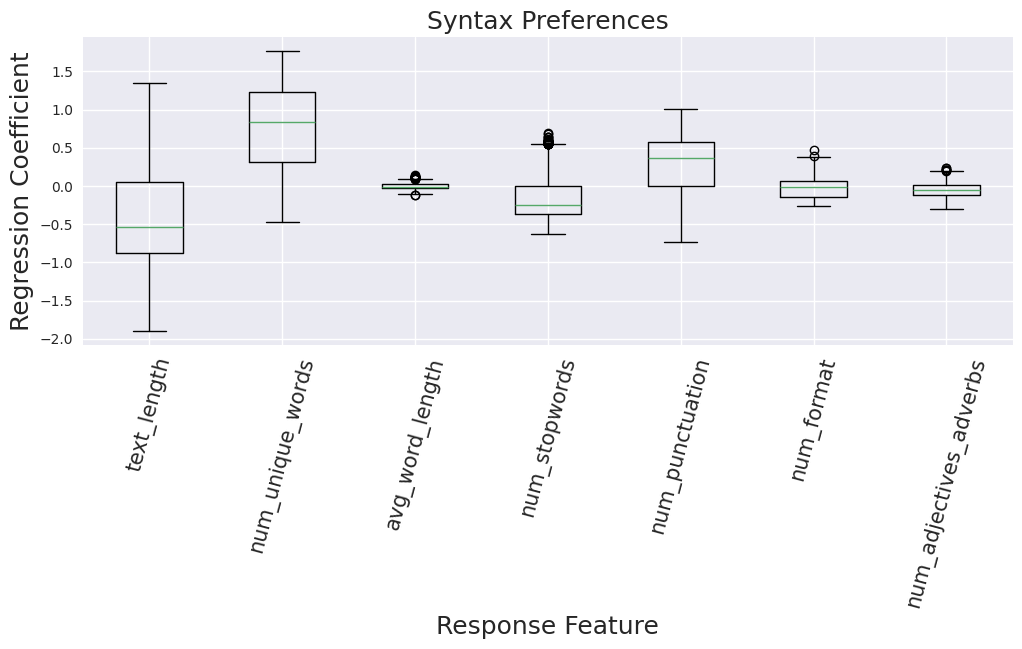

In [84]:
plt.rcParams["figure.figsize"] = (12,4)

data = [test_weights[:,i] for i in range(test_weights.shape[-1])]
plt.boxplot(data)
plt.xticks(np.arange(test_weights.shape[-1])+1, feature_list, fontsize=15, rotation=75)
plt.xlabel("Response Feature", fontsize=18)
plt.ylabel("Regression Coefficient", fontsize=18)

plt.title("Syntax Preferences", fontsize=18)
plt.savefig("../plots/syntax_features.png", bbox_inches="tight", dpi=300)
plt.show()